In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

print("\nEverything is ready!")

Pandas: 2.2.3
NumPy: 2.1.3
Scikit-learn: 1.6.1

Everything is ready!


In [4]:
# Load Excel into Pandas#
df=pd.read_excel("/content/Telco_customer_churn.xlsx")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
# Checking the dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 33


In [7]:
# Display all column names
for column in df.columns:
    print(column)

CustomerID
Count
Country
State
City
Zip Code
Lat Long
Latitude
Longitude
Gender
Senior Citizen
Partner
Dependents
Tenure Months
Phone Service
Multiple Lines
Internet Service
Online Security
Online Backup
Device Protection
Tech Support
Streaming TV
Streaming Movies
Contract
Paperless Billing
Payment Method
Monthly Charges
Total Charges
Churn Label
Churn Value
Churn Score
CLTV
Churn Reason


In [8]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [9]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [10]:
# Calculating percentages #
df["Churn Label"].value_counts(normalize=True) * 100


,proportion
Churn Label,
No,73.463013
Yes,26.536987


In [11]:
# 26.5 % customers churned #

In [12]:
# Verify churn value #
pd.crosstab(df["Churn Label"], df["Churn Value"])

Churn Value,0,1
Churn Label,,
No,5174,0
Yes,0,1869


In [13]:
# Inspecting the data properly #
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [14]:
# Check missing values #
df.isnull().sum()


,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [15]:
# Check duplicate customers #
df.duplicated().sum()

np.int64(0)

In [16]:
df["CustomerID"].duplicated().sum()

np.int64(0)

In [17]:
# Check unique values#
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

CustomerID: 7043 unique values
Count: 1 unique values
Country: 1 unique values
State: 1 unique values
City: 1129 unique values
Zip Code: 1652 unique values
Lat Long: 1652 unique values
Latitude: 1652 unique values
Longitude: 1651 unique values
Gender: 2 unique values
Senior Citizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
Tenure Months: 73 unique values
Phone Service: 2 unique values
Multiple Lines: 3 unique values
Internet Service: 3 unique values
Online Security: 3 unique values
Online Backup: 3 unique values
Device Protection: 3 unique values
Tech Support: 3 unique values
Streaming TV: 3 unique values
Streaming Movies: 3 unique values
Contract: 3 unique values
Paperless Billing: 2 unique values
Payment Method: 4 unique values
Monthly Charges: 1585 unique values
Total Charges: 6531 unique values
Churn Label: 2 unique values
Churn Value: 2 unique values
Churn Score: 85 unique values
CLTV: 3438 unique values
Churn Reason: 20 unique values


In [18]:
# Inspect categorical variables #
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 CustomerID
CustomerID
3186-AJIEK    1
3668-QPYBK    1
9237-HQITU    1
7203-OYKCT    1
9837-FWLCH    1
             ..
1066-JKSGK    1
8779-QRDMV    1
4190-MFLUW    1
0280-XJGEX    1
7892-POOKP    1
Name: count, Length: 7043, dtype: int64

 Country
Country
United States    7043
Name: count, dtype: int64

 State
State
California    7043
Name: count, dtype: int64

 City
City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Chester            4
Big Bar            4
Washington         4
Stonyford          4
Stirling City      4
Name: count, Length: 1129, dtype: int64

 Lat Long
Lat Long
34.159534, -116.425984    5
33.28156, -115.955541     5
34.201108, -116.593456    5
33.798266, -118.300237    5
33.391181, -118.421305    5
                         ..
41.505916, -120.152505    4
41.764869, -122.671316    4
41.465121, -122.380947    4
40.021787, -122.127576    4
41.737962, -123.07557     4
Name: count, Length: 165

In [19]:
# Inspect numerical columns #
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [20]:
# Check total charges#
df["Total Charges"].dtype

dtype('O')

In [21]:
# Convert total charges to numeric #
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [22]:
df["Total Charges"].dtype

dtype('float64')

In [23]:
# Check whether conversion created missing values #
df["Total Charges"].isnull().sum()

np.int64(11)

In [24]:
df[df["Total Charges"].isnull()][
    ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges"]
]

,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,NaN
2438,3115-CZMZD,0,20.25,NaN
2568,5709-LVOEQ,0,80.85,NaN
2667,4367-NUYAO,0,25.75,NaN
2856,1371-DWPAZ,0,56.05,NaN
4331,7644-OMVMY,0,19.85,NaN
4687,3213-VVOLG,0,25.35,NaN
5104,2520-SGTTA,0,20.00,NaN
5719,2923-ARZLG,0,19.70,NaN
6772,4075-WKNIU,0,73.35,NaN


In [25]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [26]:
df["Total Charges"].dtype

dtype('float64')

In [27]:
df["Total Charges"].isnull().sum()

np.int64(11)

In [28]:
df["Total Charges"] = df["Total Charges"].fillna(0)

In [29]:
df["Total Charges"].isnull().sum()

np.int64(0)

In [30]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["CustomerID"].duplicated().sum())

Duplicate rows: 0
Duplicate Customer IDs: 0


In [31]:
# Final cleaning validation- duplicates, missing values #
print("Dataset shape:", df.shape)

print("\nTotal Charges data type:")
print(df["Total Charges"].dtype)

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (7043, 33)

Total Charges data type:
float64

Missing values:
Churn Reason    5174
dtype: int64

Duplicate rows:
0


## 2. Exploratory Data Analysis (EDA)

The purpose of this exploratory analysis is to understand customer behavior, identify patterns associated with churn, and investigate the factors that may contribute to customer attrition.

In [32]:
# Overall customer churn
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [33]:
# Redoing percentage
churn_percentage = (
    df["Churn Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_percentage

,proportion
Churn Label,
No,73.46
Yes,26.54


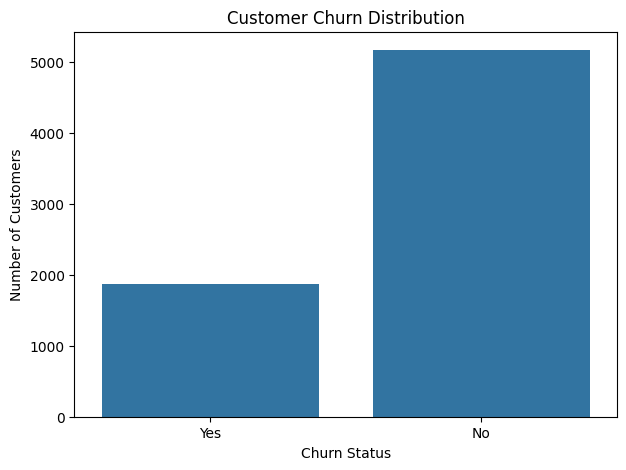

In [34]:
# First chart
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

#Interpretation

Approximately 26.5% of customers in the dataset have churned. This indicates a **meaningful customer retention challenge** and motivates further analysis to identify the characteristics and behaviors associated with churn.

In [35]:
# Does the contract type affect the churn?
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
).mul(100).round(2)

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


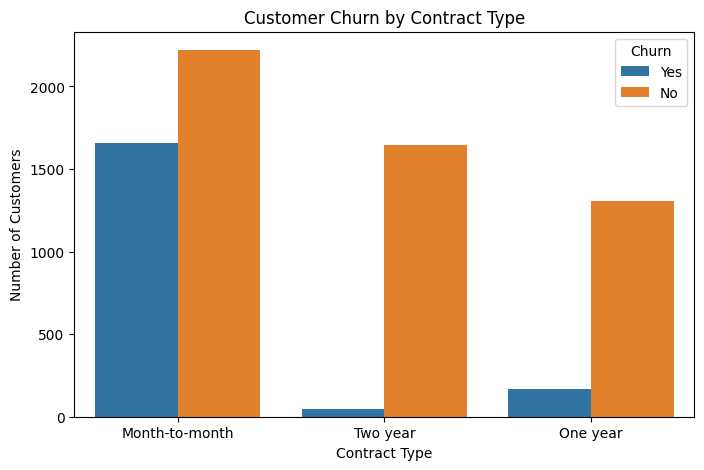

In [36]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

In [37]:
contract_churn_rate = (
    df.groupby("Contract")["Churn Value"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

contract_churn_rate

,Churn Value
Contract,
Month-to-month,42.71
One year,11.27
Two year,2.83


### Interpretation : Contract Type

Customers on month-to-month contracts display a substantially higher churn rate compared to one year and two year contract types. Longer-term contractual relationships appear to be associated with greater customer retention.

Suggestion- Encouraging suitable month-to-month customers to shift towards longer-term contracts could be explored as a potential retention strategy.

In [38]:
# Does tenure affect churn?
df.groupby("Churn Label")["Tenure Months"].agg(
    ["mean", "median"]
).round(2)

,mean,median
Churn Label,,
No,37.57,38.0
Yes,17.98,10.0


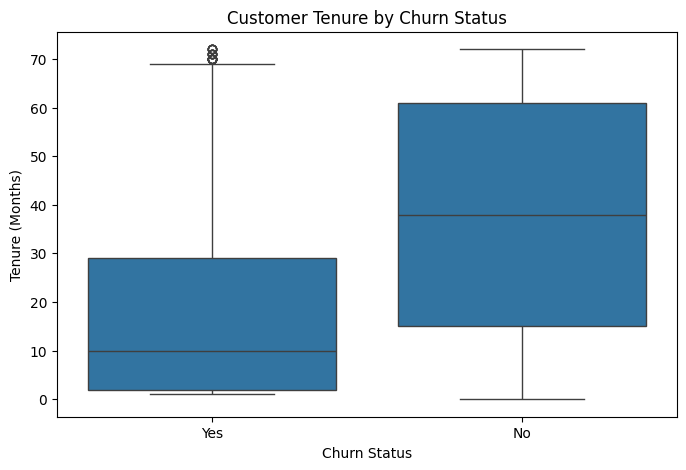

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.show()

In [40]:
# Creating customer tenure groups
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-60 Months",
        "61-72 Months"
    ]
)

In [41]:
df["Tenure Group"].value_counts().sort_index()

,count
Tenure Group,
0-12 Months,2186
13-24 Months,1024
25-48 Months,1594
49-60 Months,832
61-72 Months,1407


In [42]:
tenure_churn_rate = (
    df.groupby("Tenure Group", observed=True)["Churn Value"]
    .mean()
    .mul(100)
    .round(2)
)

tenure_churn_rate

,Churn Value
Tenure Group,
0-12 Months,47.44
13-24 Months,28.71
25-48 Months,20.39
49-60 Months,14.42
61-72 Months,6.61


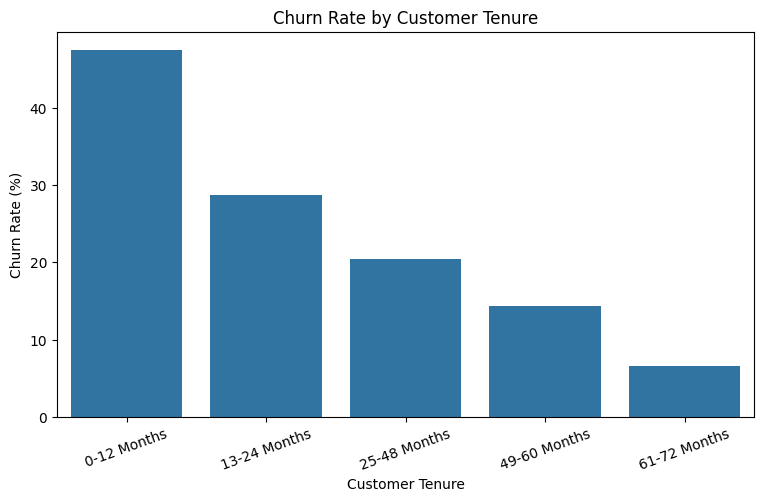

In [43]:
# Visualize tenure groups
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tenure_churn_rate.index,
    y=tenure_churn_rate.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

### **Interpretation: Tenure**
 Customers with lower tenure tend to churn more. As tenure increases, churning rate falls.


In [44]:
# Do customers with higher monthly charges churn more?
df.groupby("Churn Label")["Monthly Charges"].agg(
    ["mean", "median"]
).round(2)

,mean,median
Churn Label,,
No,61.27,64.43
Yes,74.44,79.65


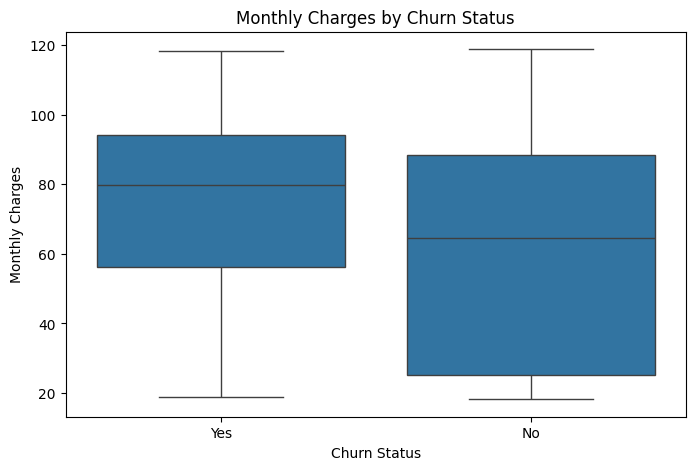

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

### **Interpretation**
Customers who face higher monthly charges tend to churn more.


In [46]:
# Internet service
internet_churn_rate = (
    df.groupby("Internet Service")["Churn Value"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

internet_churn_rate

,Churn Value
Internet Service,
Fiber optic,41.89
DSL,18.96
No,7.40


This indicates a strong connection between fiber optic service and customer churn. Further analysis is required to determine whether this relationship may also be connected to factors such as monthly charges, contract type, or support services.

In [47]:
# Payment Method
payment_churn_rate = (
    df.groupby("Payment Method")["Churn Value"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

payment_churn_rate

,Churn Value
Payment Method,
Electronic check,45.29
Mailed check,19.11
Bank transfer (automatic),16.71
Credit card (automatic),15.24


Strong association between payment method and churn rate- Customers using electronic check have the highest churn rate.

**Behavioural context**
1. Pain of paying: E checks often require manual authorization or a fresh log-in in each billing cycle. This manual process makes the transaction highly visible to the customer and one is forced to ask themselves:"Is the service still worth the money?"
2. High administrative friction: E check require customers to input/ verify account numbers. If the customer makes a typo, the check bounces or fails days later. The business then issues a failed payment notification or a penalty fee. This admininstrative headache causes the customer to abondon the service entirely, rather than retrying for the payment.

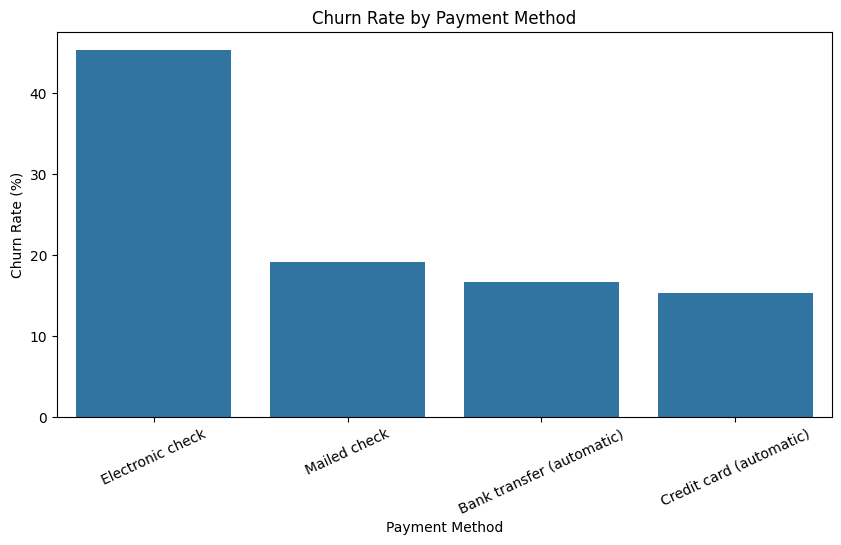

In [48]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn_rate.index,
    y=payment_churn_rate.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25)

plt.show()

In [49]:
# Tech support
support_churn_rate = (
    df.groupby("Tech Support")["Churn Value"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

support_churn_rate

,Churn Value
Tech Support,
No,41.64
Yes,15.17
No internet service,7.40


### **Interpretation: Tech Support**

Customers without tech support have a churn rate of 41.64%, compared with 15.17% among customers who have tech support.

This indicates a strong association between access to tech support and customer retention. However, this relationship should not be interpreted as causal, since customers with and without tech support may also differ in contract type, tenure, monthly charges, or other characteristics.

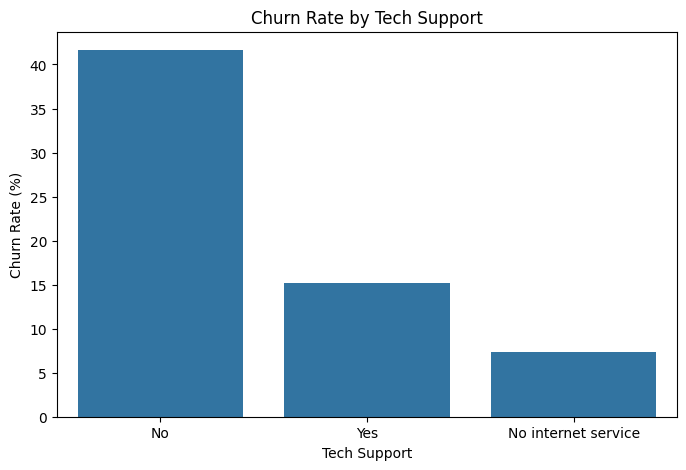

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=support_churn_rate.index,
    y=support_churn_rate.values
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

plt.show()

In [51]:
# Why are customers actually leaving?
# Isolate customers who churned
churned_customers = df[
    df["Churn Label"] == "Yes"
].copy()

print("Number of churned customers:", len(churned_customers))

Number of churned customers: 1869


In [52]:
churned_customers["Churn Reason"].value_counts().head(10)

,count
Churn Reason,
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Don't know,154
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


In [53]:
# Shows 10 most frequently reported reasons for churning

### Interpretation: Reasons for Churn

The most frequently reported churn reason is the attitude of support personnel (192 customers), closely followed by competitors offering higher download speeds (189 customers) and more data (162 customers).

 These findings suggest that retention efforts may need to address both service quality and the competitiveness of the company's services.

In [54]:
top_churn_reasons = (
    churned_customers["Churn Reason"]
    .value_counts()
    .head(10)
)

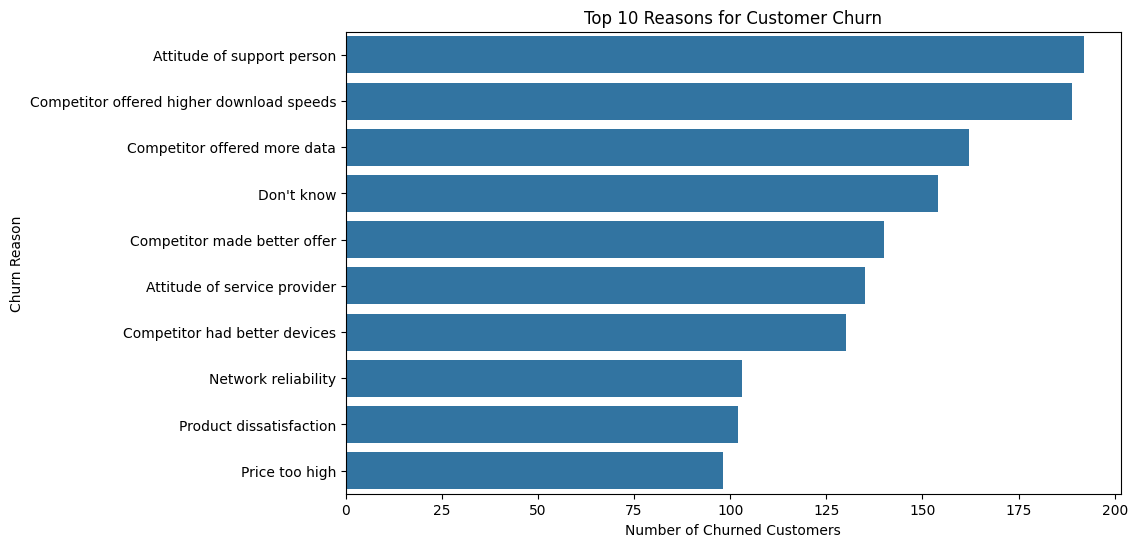

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_churn_reasons.values,
    y=top_churn_reasons.index
)

plt.title("Top 10 Reasons for Customer Churn")
plt.xlabel("Number of Churned Customers")
plt.ylabel("Churn Reason")

plt.show()

In [56]:
# Customer lifetime value analysis (CLTV)
# Value associated with a customer over their relationship with the company

# Comparing churned and retained customers
df.groupby("Churn Label")["CLTV"].agg(
    ["mean", "median"]
).round(2)

,mean,median
Churn Label,,
No,4490.92,4620.0
Yes,4149.41,4238.0


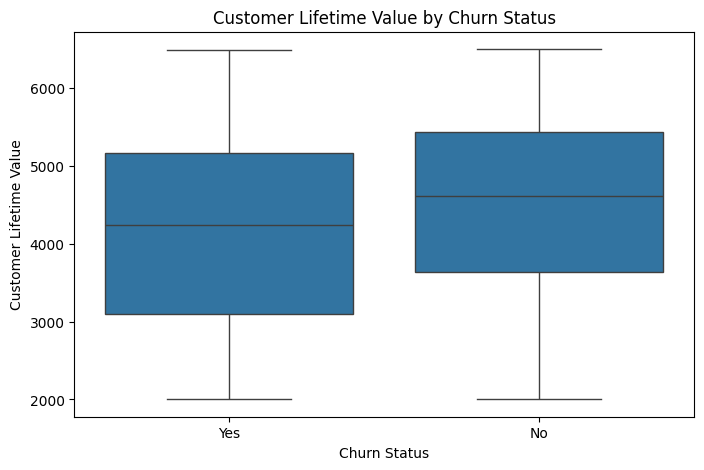

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="CLTV"
)

plt.title("Customer Lifetime Value by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Customer Lifetime Value")

plt.show()

### Interpretation: Customer Lifetime Value

Customers who remained with the company/ did not churn have a higher average CLTV/ csutomer lifetime value (4,490.92) than customers who churned (4,149.41). Median CLTV shows a similar pattern, at 4,620 for retained customers compared with 4,238 for churned customers.

## EDA Summary and Key Findings

The exploratory analysis identified several important patterns associated with customer churn:

- **Internet service:** Fiber optic customers have the highest churn rate at 41.89%, relative to 18.96% for DSL customers and 7.40% for customers without internet service.

- **Payment method:** Customers paying by electronic check have a churn rate of 45.29%, substantially higher than customers using mailed checks (19.11%), automatic bank transfers (16.71%), or automatic credit cards (15.24%).

- **Tech support:** Customers without tech support have a churn rate of 41.64%, compared with 15.17% among customers with tech support.

- **Churn reasons:** The most common reason is the attitude of support personnel, followed closely by competitors offering higher download speeds.

- **Customer lifetime value:** Retained customers have a higher average CLTV (4,490.92) than churned customers (4,149.41). Nevertheless, churned customers still represent substantial customer value.

Overall, the analysis implies that churn is associated with a combination of service characteristics, customer experience, competitive pressure, and payment behavior. These relationships will be investigated further through predictive modeling.


In [58]:
# Creating a separate ML dataset
ml_df = df.copy()

print("Original dataset:", df.shape)
print("ML dataset:", ml_df.shape)

Original dataset: (7043, 34)
ML dataset: (7043, 34)


In [59]:
# We want to predict Churn Value where 0= did not churn and 1= churned
# Removing unsuitable predictors
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

ml_df = ml_df.drop(columns=columns_to_drop)

In [60]:
if "Tenure Group" in ml_df.columns:
    ml_df = ml_df.drop(columns=["Tenure Group"])

In [61]:
# Checking what remains
print("ML dataset shape:", ml_df.shape)

print("\nColumns:")
print(ml_df.columns.tolist())

ML dataset shape: (7043, 21)

Columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


In [62]:
ml_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340


In [63]:
# Verify target= churn value
ml_df["Churn Value"].value_counts()

,count
Churn Value,
0,5174
1,1869


In [64]:
ml_df["Churn Value"].value_counts(normalize=True).mul(100).round(2)

,proportion
Churn Value,
0,73.46
1,26.54


In [65]:
# Checking missing values again
ml_df.isnull().sum()[ml_df.isnull().sum() > 0]

,0


In [66]:
# Separate X and Y ; X=info the model uses to make a prediction, Y= answer we want the model to predict; Our answer is churn value #
X = ml_df.drop("Churn Value", axis=1)
y = ml_df["Churn Value"]

In [67]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [68]:
# Check which columns are not numerical #
X.dtypes

,0
Gender,object
Senior Citizen,object
Partner,object
Dependents,object
Tenure Months,int64
Phone Service,object
Multiple Lines,object
Internet Service,object
Online Security,object
Online Backup,object


In [69]:
# One hot encode categorical variables - converting categorical variables into binary form #
print("Before encoding:", X.shape)


Before encoding: (7043, 20)


In [70]:
X = pd.get_dummies(X, drop_first=True)

In [71]:
print("After encoding:", X.shape)
# Example: Contract becomes contract_one year / contract_twoyear; values are essentially true/false


After encoding: (7043, 31)


In [72]:
# Inspecting encoded data
X.head()

,Tenure Months,Monthly Charges,Total Charges,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,3239,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,2701,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,5372,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,5003,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,5340,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [73]:
print(X.columns.tolist())

['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


In [74]:
# Split into training and testing data- 80% = training, 20%= testing
from sklearn.model_selection import train_test_split


In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [76]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 31)
Testing features: (1409, 31)
Training target: (5634,)
Testing target: (1409,)


In [77]:
# Why stratify=y? ; remember our dataset: 73.5% stayed & 26.5 % churned ; we want approximately the same ratio in both training and testing datasets
print("Original churn rate:")
print(y.mean().round(4))

print("\nTraining churn rate:")
print(y_train.mean().round(4))

print("\nTesting churn rate:")
print(y_test.mean().round(4))

Original churn rate:
0.2654

Training churn rate:
0.2654

Testing churn rate:
0.2654


In [78]:
# Scale numerical differences- standardizing the features as some vaiables operate on very different scales like senior citizen 0-1, tenure months 0-72, monthly charges 20-120
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [79]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
## We fit only on the training data (data from which model learns patterns); we do not let information from our test customers influence preprocessing learned during training


In [81]:
# Building ML Model
from sklearn.linear_model import LogisticRegression

In [82]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [83]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [84]:
# Training done, prediction on the customers it has not trained on
log_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [85]:
log_predictions = log_model.predict(X_test_scaled)

In [86]:
log_predictions[:20]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [87]:
# 0= did not churn, 1= churned & generating churn probabilities
log_probabilities = log_model.predict_proba(X_test_scaled)[:, 1]

In [88]:
log_probabilities[:10]

array([0.07503476, 0.67830593, 0.09604675, 0.47371884, 0.030985  ,
       0.61194881, 0.47502616, 0.03990711, 0.00111141, 0.38475628])

In [89]:
# Evaluating the model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [90]:
print("Logistic Regression Results")
print("---------------------------")

print("Accuracy:",
      round(accuracy_score(y_test, log_predictions), 3))

print("Precision:",
      round(precision_score(y_test, log_predictions), 3))

print("Recall:",
      round(recall_score(y_test, log_predictions), 3))

print("F1 Score:",
      round(f1_score(y_test, log_predictions), 3))

print("ROC-AUC:",
      round(roc_auc_score(y_test, log_probabilities), 3))

Logistic Regression Results
---------------------------
Accuracy: 0.802
Precision: 0.643
Recall: 0.572
F1 Score: 0.605
ROC-AUC: 0.849


### Logistic Regression Performance

The Logistic Regression model achieved:

- Accuracy: 80.2%= correct overall 80.2% of the time.
- Precision: 64.3%= of all customers flagged as churners, 64.3% actually churned.
- Recall: 57.2%= The model identified 57.2% of all actual churners.
- F1 Score: 60.5%= Combined balance of precision and recall.
- ROC-AUC: 84.9%= how good a model is at telling 2 different things apart/ good ability to rank churners above non-churners.

The model demonstrates good overall discriminatory ability, as indicated by its ROC-AUC score. However, recall is relatively moderate, meaning that a meaningful proportion of customers who actually churned were not identified by the model.

Because identifying potential churners is important for proactive customer retention, further model comparison and evaluation are required before selecting the final model.

In [91]:
# Confusion matrix- identifying what the model got right and wrong
cm = confusion_matrix(y_test, log_predictions)

cm

array([[916, 119],
       [160, 214]])

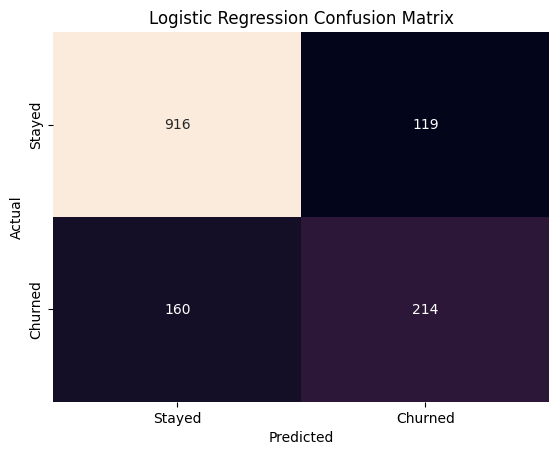

In [92]:
# Gives true negative, false positive
# plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [93]:
# How to read it - TN, FP, FN, TP
# TN = True Negative: customer stayed, model predicted stay.

# FP = False Positive: customer stayed, model predicted churn. The company might unnecessarily target them with a retention offer.

# FN = False Negative: customer churned, model predicted stay.

# TP = True Positive: customer churned, model correctly predicted churn.

In [94]:
# Print the exact confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test,
    log_predictions
).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 916
False Positives: 119
False Negatives: 160
True Positives: 214


In [95]:
# Build model 2: Random forest
# Unlike Logistic Regression, Random Forest can capture more complex nonlinear relationships and interactions without us specifying them manually

In [96]:
# Import random forest
from sklearn.ensemble import RandomForestClassifier

In [97]:
# Create model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
# n_estimators= 200 means we are constructing 200 decision trees

In [98]:
# Train
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [99]:
# Not x_train_scaled as random forest does not require feature scaling like logistic regression
# Predict
rf_predictions = rf_model.predict(X_test)

In [100]:
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

In [101]:
# Evaluate random forest
print("Random Forest Results")
print("---------------------")

print("Accuracy:",
      round(accuracy_score(y_test, rf_predictions), 3))

print("Precision:",
      round(precision_score(y_test, rf_predictions), 3))

print("Recall:",
      round(recall_score(y_test, rf_predictions), 3))

print("F1 Score:",
      round(f1_score(y_test, rf_predictions), 3))

print("ROC-AUC:",
      round(roc_auc_score(y_test, rf_probabilities), 3))

Random Forest Results
---------------------
Accuracy: 0.796
Precision: 0.644
Recall: 0.521
F1 Score: 0.576
ROC-AUC: 0.841


In [102]:
# Compare
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, rf_predictions)
    ],

    "Precision": [
        precision_score(y_test, log_predictions),
        precision_score(y_test, rf_predictions)
    ],

    "Recall": [
        recall_score(y_test, log_predictions),
        recall_score(y_test, rf_predictions)
    ],

    "F1 Score": [
        f1_score(y_test, log_predictions),
        f1_score(y_test, rf_predictions)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, log_probabilities),
        roc_auc_score(y_test, rf_probabilities)
    ]
})

model_results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802,0.643,0.572,0.605,0.849
1,Random Forest,0.796,0.644,0.521,0.576,0.841


In [103]:
# Logistic regression over random forest

In [104]:
# Improve logistic regression
# Currently logistic regression does this : Predicted probability
# Customer A = 0.12 =Stay
# Customer B = 0.34 = Stay
# Customer C = 0.48 = Stay
# Customer D = 0.51 = CHURN
# Customer E = 0.78 = CHURN

# Someone with 48% churn probability gets classified as stay as the deafult threshold is 0.5; probability >= 0.5 means churn and probability <= 0.5 means stay

In [105]:
# Test several thresholds
log_probabilities

array([0.07503476, 0.67830593, 0.09604675, ..., 0.18442578, 0.00527645,
       0.00224129])

In [106]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:

    predictions = (
        log_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Precision,Recall,F1 Score
0,0.30,0.530,0.743,0.618
1,0.35,0.563,0.717,0.631
2,0.40,0.580,0.671,0.622
3,0.45,0.606,0.628,0.617
4,0.50,0.643,0.572,0.605


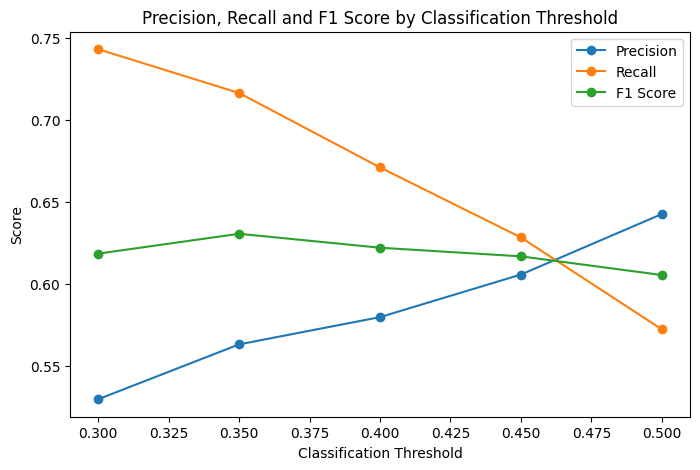

In [107]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.title("Precision, Recall and F1 Score by Classification Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()

plt.show()

In [108]:
# Compare actual customer counts
threshold_counts = []

for threshold in thresholds:

    predictions = (
        log_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    threshold_counts.append({
        "Threshold": threshold,
        "True Positives": tp,
        "False Negatives": fn,
        "False Positives": fp,
        "True Negatives": tn
    })

threshold_counts_df = pd.DataFrame(threshold_counts)

threshold_counts_df

,Threshold,True Positives,False Negatives,False Positives,True Negatives
0,0.30,278,96,247,788
1,0.35,268,106,208,827
2,0.40,251,123,182,853
3,0.45,235,139,153,882
4,0.50,214,160,119,916


In [109]:
# At 0.5 threshold, model is capturing only 214 churners out of 214+ 160= 374 actual churners
# At 0.4 threshold, model is capturing 251 churners out of 251+ 123= 374 actual churners but false positives(actual stay but model predicts churn) increase by 63

In [110]:
# Calculate exact 0.4 metrics
chosen_threshold = 0.40

final_predictions = (
    log_probabilities >= chosen_threshold
).astype(int)

print("Logistic Regression — Threshold 0.40")
print("------------------------------------")

print(
    "Accuracy:",
    round(accuracy_score(y_test, final_predictions), 3)
)

print(
    "Precision:",
    round(precision_score(y_test, final_predictions), 3)
)

print(
    "Recall:",
    round(recall_score(y_test, final_predictions), 3)
)

print(
    "F1 Score:",
    round(f1_score(y_test, final_predictions), 3)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, log_probabilities), 3)
)

Logistic Regression — Threshold 0.40
------------------------------------
Accuracy: 0.784
Precision: 0.58
Recall: 0.671
F1 Score: 0.622
ROC-AUC: 0.849


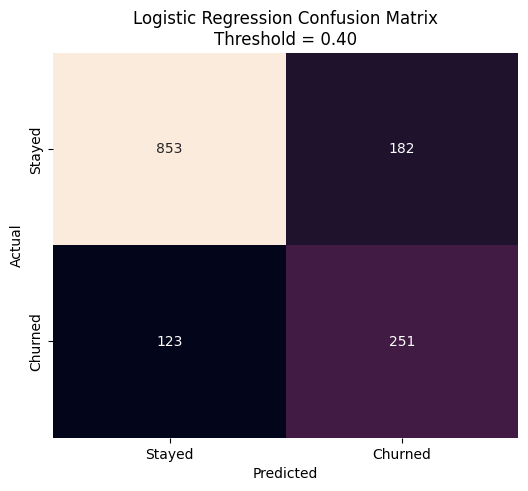

In [111]:
# Final confusion matrix
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title(
    "Logistic Regression Confusion Matrix\nThreshold = 0.40"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Classification Threshold Selection

The default Logistic Regression classification threshold of 0.50 identified 214 of the 374 actual churners in the test sample, corresponding to a recall of 57.2%.

Because the business objective is to identify customers at risk before they leave, alternative classification thresholds were evaluated.

Reducing the threshold to 0.40 increased the number of correctly identified churners from 214 to 251 and reduced false negatives from 160 to 123. This improvement comes at the cost of increasing false positives from 119 to 182.

A threshold of 0.40 was therefore selected as an illustrative business-oriented operating threshold because it improves the identification of at-risk customers while maintaining a more moderate false-positive burden than still lower thresholds.


In [112]:
# What factors are associated with higher or lower predicted churn risk?
# Extract coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
11,Internet Service_Fiber optic,0.694499
2,Total Charges,0.506168
22,Streaming TV_Yes,0.241573
24,Streaming Movies_Yes,0.228894
10,Multiple Lines_Yes,0.214840
29,Payment Method_Electronic check,0.177579
27,Paperless Billing_Yes,0.176168
6,Partner_Yes,0.147205
18,Device Protection_Yes,0.033653
30,Payment Method_Mailed check,0.031371


Positive coefficient- associated with higher predicted churn; Negative ceofficient associated with lower predicted churn

In [113]:
# Top churn-increasing features
top_positive = coefficients.head(10)

top_positive

,Feature,Coefficient
11,Internet Service_Fiber optic,0.694499
2,Total Charges,0.506168
22,Streaming TV_Yes,0.241573
24,Streaming Movies_Yes,0.228894
10,Multiple Lines_Yes,0.214840
29,Payment Method_Electronic check,0.177579
27,Paperless Billing_Yes,0.176168
6,Partner_Yes,0.147205
18,Device Protection_Yes,0.033653
30,Payment Method_Mailed check,0.031371


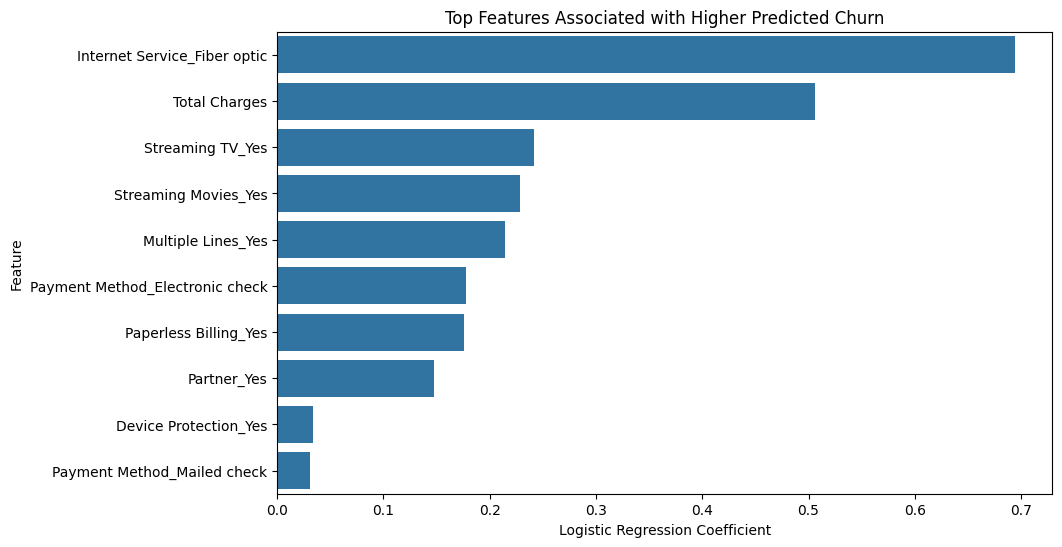

In [114]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Associated with Higher Predicted Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [115]:
# Top churn reducing features
top_negative = coefficients.tail(10).sort_values(
    "Coefficient"
)

top_negative

,Feature,Coefficient
0,Tenure Months,-1.264254
1,Monthly Charges,-0.786326
7,Dependents_Yes,-0.692962
26,Contract_Two year,-0.571244
25,Contract_One year,-0.300581
14,Online Security_Yes,-0.124047
20,Tech Support_Yes,-0.109045
23,Streaming Movies_No internet service,-0.082596
17,Device Protection_No internet service,-0.082596
19,Tech Support_No internet service,-0.082596


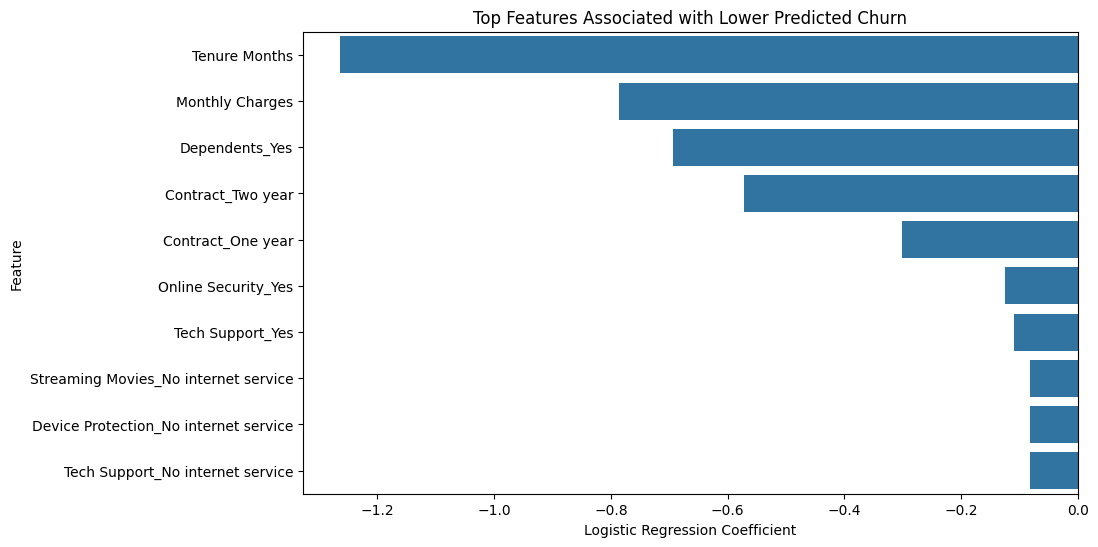

In [116]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Associated with Lower Predicted Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [117]:
coefficients.head(10)

,Feature,Coefficient
11,Internet Service_Fiber optic,0.694499
2,Total Charges,0.506168
22,Streaming TV_Yes,0.241573
24,Streaming Movies_Yes,0.228894
10,Multiple Lines_Yes,0.214840
29,Payment Method_Electronic check,0.177579
27,Paperless Billing_Yes,0.176168
6,Partner_Yes,0.147205
18,Device Protection_Yes,0.033653
30,Payment Method_Mailed check,0.031371


In [118]:
coefficients.tail(10)

,Feature,Coefficient
19,Tech Support_No internet service,-0.082596
17,Device Protection_No internet service,-0.082596
23,Streaming Movies_No internet service,-0.082596
20,Tech Support_Yes,-0.109045
14,Online Security_Yes,-0.124047
25,Contract_One year,-0.300581
26,Contract_Two year,-0.571244
7,Dependents_Yes,-0.692962
1,Monthly Charges,-0.786326
0,Tenure Months,-1.264254


### Model Interpretation

The Logistic Regression coefficients provide insight into the characteristics associated with predicted customer churn after accounting for the other variables included in the model.

Fiber optic internet service shows one of the strongest positive associations with predicted churn, consistent with the earlier exploratory analysis in which fiber optic customers exhibited a relatively high churn rate.

Longer customer tenure has the strongest negative coefficient, indicating that established customers are associated with substantially lower predicted churn risk. Longer-term contracts also show negative coefficients, particularly two-year contracts.

Having dependents, online security, and tech support are also associated with lower predicted churn.

Some multivariate model relationships differ from the patterns observed during exploratory analysis. For example, the coefficient on Monthly Charges becomes negative after controlling for other customer and service characteristics. This highlights the distinction between simple bivariate associations and conditional relationships estimated by a multivariate model.

These coefficients represent predictive associations rather than causal effects.

**Predicted churn probability + CLTV = Retention priority**

In [119]:
# Create a customer level results table
results_df = df.loc[X_test.index].copy()

In [120]:
# Attach model probabilities
results_df["Predicted Churn Probability"] = log_probabilities

In [122]:
# Threshold prediction of 0.4
results_df["Predicted Churn"] = (
    results_df["Predicted Churn Probability"] >= 0.40
).astype(int)

In [123]:
results_df[
    [
        "CustomerID",
        "Churn Value",
        "Predicted Churn Probability",
        "Predicted Churn",
        "CLTV"
    ]
].head(10)

,CustomerID,Churn Value,Predicted Churn Probability,Predicted Churn,CLTV
2196,4376-KFVRS,0,0.075035,0,4842
3549,2754-SDJRD,0,0.678306,1,5157
3515,9917-KWRBE,0,0.096047,0,2894
5162,0365-GXEZS,0,0.473719,1,2831
4642,9385-NXKDA,0,0.030985,0,4324
6096,4686-UXDML,0,0.611949,1,2113
4504,2227-JRSJX,0,0.475026,1,5324
4067,4830-FAXFM,0,0.039907,0,2378
6233,1830-IPXVJ,0,0.001111,0,6108
430,4690-LLKUA,1,0.384756,0,3797


In [124]:
# Create churn risk groups
results_df["Risk Level"] = pd.cut(
    results_df["Predicted Churn Probability"],
    bins=[0, 0.30, 0.40, 0.60, 1.0],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    include_lowest=True
)

In [125]:
results_df["Risk Level"].value_counts()

,count
Risk Level,
Low,884
Very High,227
High,206
Moderate,92


In [126]:
# Find the CLTV cutoff
cltv_median = df["CLTV"].median()

print("Median CLTV:", cltv_median)

Median CLTV: 4527.0


In [127]:
# Classify customer value
results_df["Customer Value"] = np.where(
    results_df["CLTV"] >= cltv_median,
    "High Value",
    "Lower Value"
)

In [128]:
results_df["Customer Value"].value_counts()

,count
Customer Value,
Lower Value,706
High Value,703


In [129]:
# Q) which customers are both valuable and at a risk of leaving?
def retention_priority(row):

    if (
        row["Predicted Churn Probability"] >= 0.40
        and row["Customer Value"] == "High Value"
    ):
        return "Priority Retention"

    elif row["Predicted Churn Probability"] >= 0.40:
        return "Retention Candidate"

    elif row["Customer Value"] == "High Value":
        return "Relationship Maintenance"

    else:
        return "Lower Priority"


results_df["Retention Priority"] = results_df.apply(
    retention_priority,
    axis=1
)

In [130]:
results_df["Retention Priority"].value_counts()

,count
Retention Priority,
Relationship Maintenance,541
Lower Priority,435
Retention Candidate,271
Priority Retention,162


In [131]:
# Look at highest priority customers
priority_customers = (
    results_df[
        results_df["Retention Priority"] == "Priority Retention"
    ]
    .sort_values(
        ["Predicted Churn Probability", "CLTV"],
        ascending=False
    )
)

In [132]:
priority_customers[
    [
        "CustomerID",
        "Predicted Churn Probability",
        "CLTV",
        "Contract",
        "Internet Service",
        "Tech Support",
        "Payment Method"
    ]
].head(10)

,CustomerID,Predicted Churn Probability,CLTV,Contract,Internet Service,Tech Support,Payment Method
886,5178-LMXOP,0.884325,5795,Month-to-month,Fiber optic,No,Electronic check
2567,6630-UJZMY,0.850882,5251,Month-to-month,Fiber optic,No,Electronic check
1818,0295-PPHDO,0.847415,5962,Month-to-month,Fiber optic,No,Electronic check
3732,4927-WWOOZ,0.839859,4889,Month-to-month,Fiber optic,No,Electronic check
590,7181-BQYBV,0.830055,4811,Month-to-month,Fiber optic,No,Electronic check
598,7180-PISOG,0.828875,5554,Month-to-month,Fiber optic,No,Electronic check
731,6023-YEBUP,0.828863,5351,Month-to-month,Fiber optic,No,Electronic check
4845,8161-QYMTT,0.826382,5259,Month-to-month,Fiber optic,No,Electronic check
362,7249-WBIYX,0.813912,5146,Month-to-month,Fiber optic,No,Electronic check
4341,2545-EBUPK,0.813206,5039,Month-to-month,Fiber optic,No,Electronic check


In [133]:
results_df["Retention Priority"].value_counts()

,count
Retention Priority,
Relationship Maintenance,541
Lower Priority,435
Retention Candidate,271
Priority Retention,162


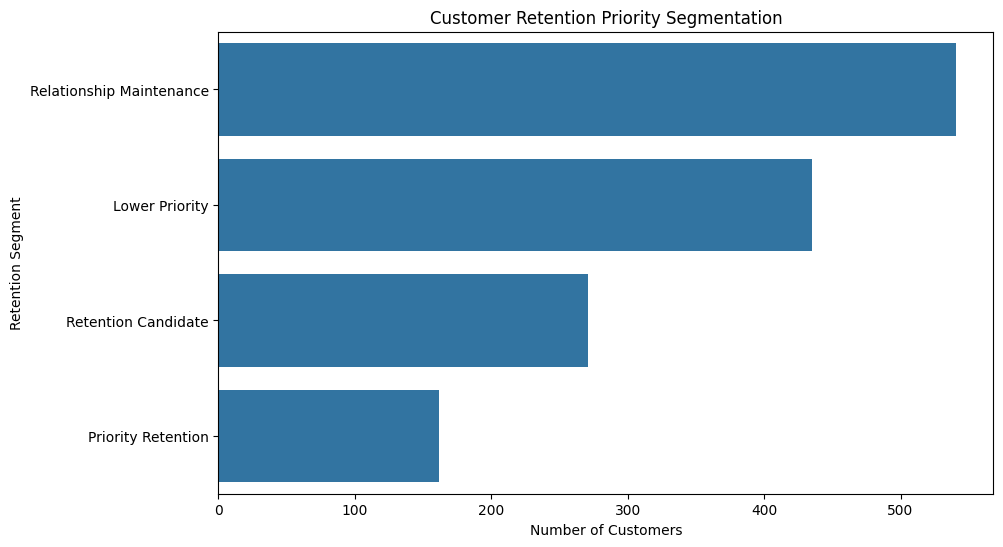

In [134]:
priority_counts = (
    results_df["Retention Priority"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=priority_counts.values,
    y=priority_counts.index
)

plt.title("Customer Retention Priority Segmentation")
plt.xlabel("Number of Customers")
plt.ylabel("Retention Segment")

plt.show()

In [135]:
# Quantify the priority group
priority_summary = (
    results_df
    .groupby("Retention Priority")
    .agg(
        Customers=("CustomerID", "count"),
        Average_CLTV=("CLTV", "mean"),
        Average_Churn_Probability=(
            "Predicted Churn Probability",
            "mean"
        )
    )
    .round(2)
)

priority_summary

,Customers,Average_CLTV,Average_Churn_Probability
Retention Priority,,,
Lower Priority,435,3523.11,0.13
Priority Retention,162,5278.75,0.61
Relationship Maintenance,541,5402.16,0.10
Retention Candidate,271,3204.06,0.61


In [136]:
# Calculate CLTV represented by priority customers
priority_cltv = priority_customers["CLTV"].sum()

print(
    "Total CLTV represented by Priority Retention customers:",
    priority_cltv
)

Total CLTV represented by Priority Retention customers: 855158


## Business Recommendations

The analysis suggests that customer retention efforts should be targeted rather than applied uniformly across the customer base.

### 1. Prioritize high-value customers with elevated churn risk

Using a 40% churn-probability threshold together with the median CLTV of 4,527, the analysis identified 162 customers in the test sample as **Priority Retention** customers.

These customers combine above-median customer lifetime value with elevated predicted churn risk, making them a logical group for proactive retention efforts.

### 2. Investigate the fiber optic customer experience

Fiber optic customers exhibited a substantially higher observed churn rate than DSL customers. Fiber optic service was also positively associated with predicted churn in the Logistic Regression model.

The company should investigate potential underlying issues such as service reliability, pricing, support experience, and competitive alternatives rather than assuming that fiber optic service itself causes churn.

### 3. Strengthen customer support

Customers without tech support exhibited substantially higher observed churn. In addition, the attitude of support personnel was the most frequently reported churn reason.

Improving support quality and proactively assisting high-risk customers may therefore represent an important retention opportunity.

### 4. Review competitive positioning

Several leading reported churn reasons involved competitors offering higher download speeds, more data, better devices, or better overall offers.

Retention strategies should therefore consider competitive offers and service differentiation, particularly for customers already identified as high risk.

### 5. Examine payment and contract behavior

Electronic-check customers exhibited substantially higher churn than customers using other payment methods, while longer-term contracts were associated with lower predicted churn.

These characteristics could be incorporated into retention targeting, while recognizing that the observed relationships are associative rather than necessarily causal.

### 6. Use risk-based retention targeting

Rather than offering retention incentives to all customers, the company could use predicted churn probability together with customer value to prioritize interventions.

This allows limited retention resources to be concentrated on customers for whom churn risk and customer value are simultaneously high.

## Conclusion

This project developed a customer churn analytics framework combining exploratory analysis, machine learning, and customer-value segmentation.

Logistic Regression outperformed the tested Random Forest model and achieved a ROC-AUC of 0.849. Adjusting the classification threshold from 0.50 to 0.40 increased recall from 57.2% to 67.1%, allowing the model to identify a larger proportion of actual churners.

The predictive model was then combined with Customer Lifetime Value (CLTV) to move beyond churn prediction toward actionable retention prioritization. Using elevated predicted churn risk and above-median CLTV, 162 customers in the test sample were classified as Priority Retention customers.

The analysis demonstrates how predictive modeling can support targeted customer-retention decisions rather than treating all customers or all predicted churners equally.


In [137]:
# Import joblib
import joblib

In [139]:
# Save logistic regression model
joblib.dump(
    log_model,
    "logistic_churn_model.pkl"
)

['logistic_churn_model.pkl']

In [140]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [141]:
# Save exact feauture structure
model_features = X.columns.tolist()

joblib.dump(
    model_features,
    "model_features.pkl"
)

['model_features.pkl']

In [142]:
print("Number of model features:", len(model_features))
print(model_features)

Number of model features: 31
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


In [143]:
# Save our business parameters
business_parameters = {
    "churn_threshold": 0.40,
    "cltv_median": 4527
}

joblib.dump(
    business_parameters,
    "business_parameters.pkl"
)

['business_parameters.pkl']

In [144]:
import os

files_to_check = [
    "logistic_churn_model.pkl",
    "scaler.pkl",
    "model_features.pkl",
    "business_parameters.pkl"
]

for file in files_to_check:
    print(file, "→", os.path.exists(file))

logistic_churn_model.pkl → True
scaler.pkl → True
model_features.pkl → True
business_parameters.pkl → True
